# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
#Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
#Load Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

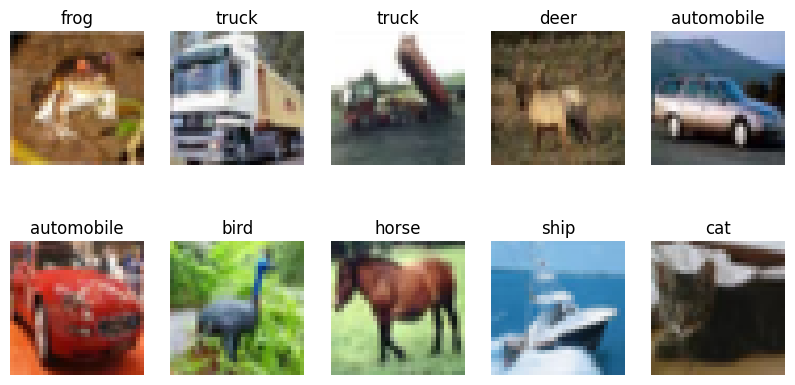

In [3]:
#Visualize Images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
#ANN Data Preparation
X_train_ann = X_train.reshape(-1, 32*32*3)
X_test_ann = X_test.reshape(-1, 32*32*3)

print(X_train_ann.shape)

(50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
#ANN Basic Model
ann_basic = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_basic.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_basic = ann_basic.fit(
    X_train_ann, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

ann_basic_acc = ann_basic.evaluate(
    X_test_ann,
    y_test,
    verbose=0
)[1]

print("ANN Basic Accuracy:", ann_basic_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3161 - loss: 1.8975 - val_accuracy: 0.3625 - val_loss: 1.7568
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3903 - loss: 1.6968 - val_accuracy: 0.3863 - val_loss: 1.6894
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4258 - loss: 1.6054 - val_accuracy: 0.4336 - val_loss: 1.5992
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4464 - loss: 1.5501 - val_accuracy: 0.4436 - val_loss: 1.5679
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4656 - loss: 1.4976 - val_accuracy: 0.4614 - val_loss: 1.5449
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4703 - loss: 1.4771 - val_accuracy: 0.4696 - val_loss: 1.5062
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4849 - loss: 1.4390 - val_accuracy: 0.4668 - val_loss: 1.5137
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4923 - loss: 1.4132 - val_accuracy: 0.

In [6]:
#Deep ANN Model
ann_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_deep = ann_deep.fit(
    X_train_ann, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

ann_deep_acc = ann_deep.evaluate(
    X_test_ann,
    y_test,
    verbose=0
)[1]

print("Deep ANN Accuracy:", ann_deep_acc)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3021 - loss: 1.9113 - val_accuracy: 0.3414 - val_loss: 1.8313
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3855 - loss: 1.7122 - val_accuracy: 0.3872 - val_loss: 1.6996
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4147 - loss: 1.6264 - val_accuracy: 0.3977 - val_loss: 1.6689
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4378 - loss: 1.5633 - val_accuracy: 0.4206 - val_loss: 1.6261
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4554 - loss: 1.5140 - val_accuracy: 0.4275 - val_loss: 1.6011
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4705 - loss: 1.4790 - val_accuracy: 0.4530 - val_loss: 1.5306
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4791 - loss: 1.4483 - val_accuracy: 0.4462 - val_loss: 1.5465
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4933 - loss: 1.4138 - val_accuracy: 0.

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
#CNN Basic Model
cnn_basic = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn_basic.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_basic = cnn_basic.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

cnn_basic_acc = cnn_basic.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN Basic Accuracy:", cnn_basic_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4243 - loss: 1.5681 - val_accuracy: 0.5407 - val_loss: 1.2838
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5872 - loss: 1.1666 - val_accuracy: 0.6353 - val_loss: 1.0533
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6517 - loss: 0.9944 - val_accuracy: 0.6500 - val_loss: 1.0091
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6915 - loss: 0.8804 - val_accuracy: 0.6581 - val_loss: 0.9813
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7267 - loss: 0.7882 - val_accuracy: 0.7003 - val_loss: 0.8673
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7499 - loss: 0.7157 - val_accuracy: 0.7037 - val_loss: 0.8715
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7733 - loss: 0.6502 - val_accuracy: 0.6972 - val_loss: 0.9051
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7914 - loss: 0.6008 

In [8]:
#CNN + Batch Normalization
cnn_bn = models.Sequential([
    layers.Conv2D(32,(3,3),padding='same',
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = cnn_bn.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

cnn_bn_acc = cnn_bn.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN BatchNorm Accuracy:", cnn_bn_acc)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5325 - loss: 1.3191 - val_accuracy: 0.5629 - val_loss: 1.2127
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6795 - loss: 0.9118 - val_accuracy: 0.5868 - val_loss: 1.2007
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7401 - loss: 0.7374 - val_accuracy: 0.6583 - val_loss: 1.0614
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7837 - loss: 0.6183 - val_accuracy: 0.6979 - val_loss: 0.9190
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8231 - loss: 0.5040 - val_accuracy: 0.7321 - val_loss: 0.8108
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8548 - loss: 0.4098 - val_accuracy: 0.7334 - val_loss: 0.8397
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8837 - loss: 0.3300 - val_accuracy: 0.6952 - val_loss: 1.0497
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9062 - loss: 0.2643 -

In [9]:
#CNN + DropOut
cnn_dropout = models.Sequential([
    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

cnn_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = cnn_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

cnn_dropout_acc = cnn_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN Dropout Accuracy:", cnn_dropout_acc)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3616 - loss: 1.7235 - val_accuracy: 0.4887 - val_loss: 1.4291
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5114 - loss: 1.3566 - val_accuracy: 0.5648 - val_loss: 1.2233
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5714 - loss: 1.2129 - val_accuracy: 0.6107 - val_loss: 1.0889
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6149 - loss: 1.0996 - val_accuracy: 0.6384 - val_loss: 1.0270
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6405 - loss: 1.0282 - val_accuracy: 0.6558 - val_loss: 0.9844
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6626 - loss: 0.9615 - val_accuracy: 0.6645 - val_loss: 0.9599
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6796 - loss: 0.9089 - val_accuracy: 0.6877 - val_loss: 0.9022
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6923 - loss: 0.8760 -

## 📈 Compare Learning Curves

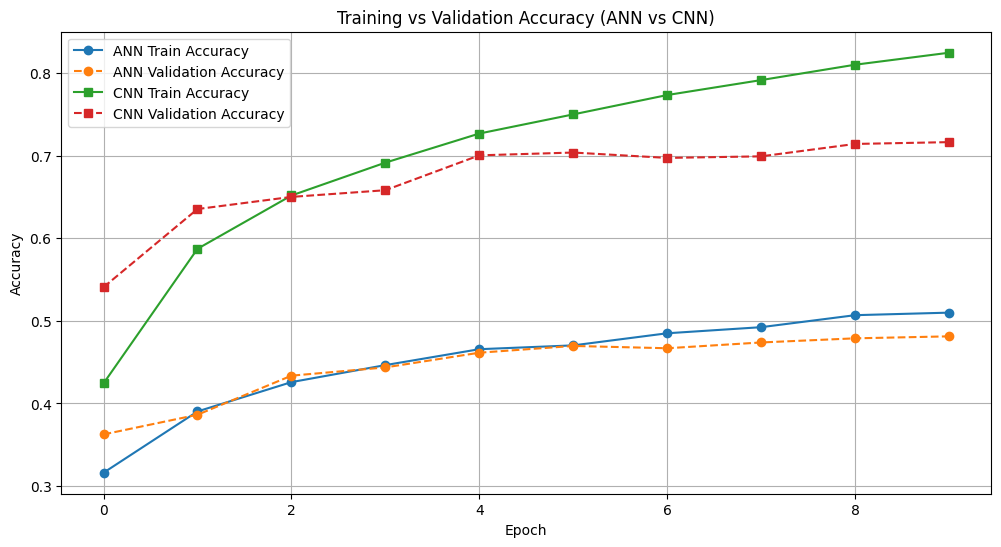

In [10]:
#Accuracy Comparison Graph
plt.figure(figsize=(12,6))

plt.plot(history_ann_basic.history['accuracy'],
         marker='o',
         label='ANN Train Accuracy')

plt.plot(history_ann_basic.history['val_accuracy'],
         marker='o',
         linestyle='--',
         label='ANN Validation Accuracy')

plt.plot(history_cnn_basic.history['accuracy'],
         marker='s',
         label='CNN Train Accuracy')

plt.plot(history_cnn_basic.history['val_accuracy'],
         marker='s',
         linestyle='--',
         label='CNN Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (ANN vs CNN)")
plt.grid(True)
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
#Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [12]:
#CNN + Augmentation
cnn_aug = models.Sequential([
    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

cnn_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_aug = cnn_aug.fit(
    datagen.flow(X_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(X_test,y_test),
    callbacks=[early_stop]
)

cnn_aug_acc = cnn_aug.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN Augmentation Accuracy:", cnn_aug_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.3476 - loss: 1.7562 - val_accuracy: 0.4849 - val_loss: 1.4026
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.4776 - loss: 1.4444 - val_accuracy: 0.5514 - val_loss: 1.2390
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5345 - loss: 1.3117 - val_accuracy: 0.5956 - val_loss: 1.1490
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.5665 - loss: 1.2309 - val_accuracy: 0.6434 - val_loss: 1.0200
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5852 - loss: 1.1693 - val_accuracy: 0.6451 - val_loss: 1.0074
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.6064 - loss: 1.1276 - val_accuracy: 0.6362 - val_loss: 1.0389
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6219 - loss: 1.0875 - val_accuracy: 0.6740 - val_loss: 0.9410
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6361 - loss: 1.0496 - 

In [13]:
#Classification Report
pred = cnn_aug.predict(X_test)
pred_classes = np.argmax(pred,axis=1)

print(
    classification_report(
        y_test,
        pred_classes,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    airplane       0.79      0.78      0.78      1000
  automobile       0.82      0.91      0.86      1000
        bird       0.78      0.54      0.64      1000
         cat       0.64      0.50      0.56      1000
        deer       0.75      0.65      0.69      1000
         dog       0.66      0.68      0.67      1000
        frog       0.67      0.91      0.77      1000
       horse       0.69      0.85      0.77      1000
        ship       0.90      0.80      0.85      1000
       truck       0.79      0.86      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.74     10000
weighted avg       0.75      0.75      0.74     10000



# 📊 Final Comparison Table

In [14]:
#Accuracy Comparison
results = pd.DataFrame({
    'Model':[
        'ANN Basic',
        'Deep ANN',
        'CNN Basic',
        'CNN BatchNorm',
        'CNN Dropout',
        'CNN Augmentation'
    ],
    'Accuracy':[
        ann_basic_acc,
        ann_deep_acc,
        cnn_basic_acc,
        cnn_bn_acc,
        cnn_dropout_acc,
        cnn_aug_acc
    ]
})
results['Accuracy (%)']=(
    results['Accuracy']*100
).round(2)
results=results.sort_values(
    by='Accuracy',
    ascending=False
)
results.reset_index(
    drop=True,
    inplace=True
)
print(results)

              Model  Accuracy  Accuracy (%)
0  CNN Augmentation    0.7474         74.74
1         CNN Basic    0.7121         71.21
2       CNN Dropout    0.6962         69.62
3     CNN BatchNorm    0.6863         68.63
4          Deep ANN    0.4910         49.10
5         ANN Basic    0.4866         48.66


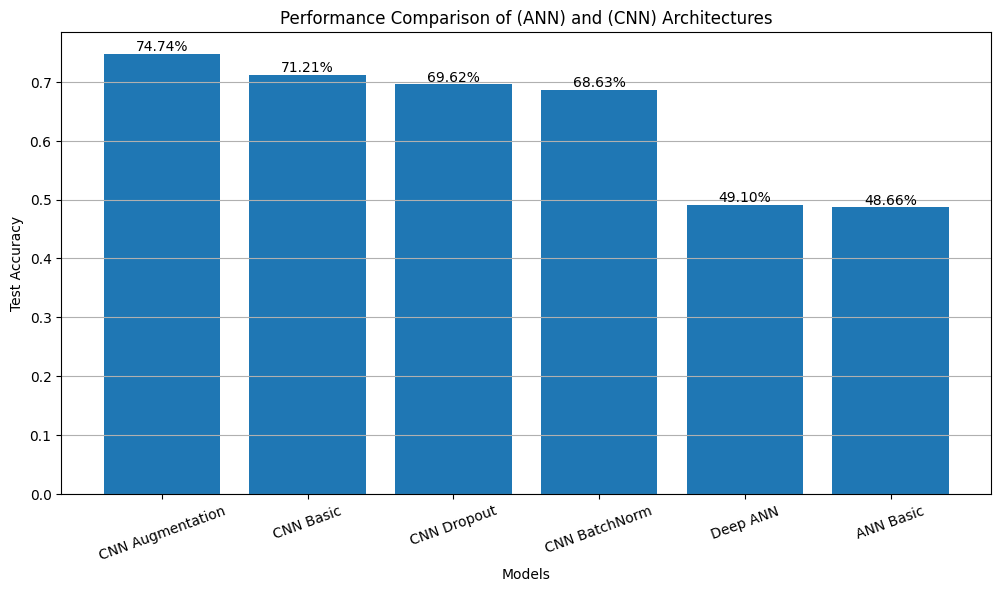

In [15]:
# Performance Comparison Graph of Different Models
plt.figure(figsize=(12,6))

bars = plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title("Performance Comparison of (ANN) and (CNN) Architectures")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.005,
        f'{y:.2%}',
        ha='center'
    )

plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

# Observation

- Deep ANN and ANN Basic achieved the lowest results, with accuracies of 49.10% and 48.66%, respectively, highlighting the limitations of fully connected layers when handling spatial image data.
- CNN BatchNorm achieved 68.63% accuracy, meaning it did not provide a performance improvement over the Basic CNN model in this specific setup.
- CNN Dropout achieved 69.62% accuracy, which was slightly lower than the Basic CNN model in this experiment.
- CNN-based models consistently outperformed ANN-based models on the CIFAR-10 dataset by a significant margin.
- CNN Basic achieved 71.21% accuracy, demonstrating the inherent effectiveness of convolutional architectures for image classification tasks over standard dense networks.
- CNN with Data Augmentation achieved the highest accuracy of 74.74%, making it the best-performing model overall and demonstrating the power of expanding the training dataset's variety.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**